# Geometric Models with Lift

In [1]:
!uv pip install scipy matplotlib seaborn pyarrow pandas --quiet

In [2]:
from scipy.stats import linregress
from lefts import leaf, lift
import matplotlib.pyplot as plt
import seaborn as sns

import polars as pl
import numpy as np

### Introduction


Lots of data has a geometric structure - images exist on a 2d plane, geospatial data lives on either a 2d plane or a curved surface of a sphere depending on your perspective, and options contract prices live on a 1D price-manifold, where each location is a different delta or strike price. Usually, dealing with geometric structure requires using sophisticated techniques like Gaussian Processes or convolutional networks.

This tutorial shows how lefts lets you model geometry via simpler models. We will simulate a time series of options data, where each data point is autocorrelated across time with contracts that are nearby in delta-space. We will train a number of linear models that 'cover' delta-space, then interpolate between them, all in a single lefts command.

For the un-initiated, options are financial derivatives that give you an insurance on a stock or future. Every options contract has a 'strike price', below which the insurance starts paying out. Many, many options contracts exist at once for a single stock, each with different strike prices. Intuitively, contracts with similar strike prices should have similar value. If you value insurance against stock going down 10% at \\$100, it wouldn't make sense to value insurance against stock going down 10.001% at anything much less than \\$100, since if one pays out it is very likely the other does too.

This is what gives options their geometric structure - if you want to know what the price of an option with a specific strike price should be, you can look at it's neighbours with similar prices to form a pretty good guess. 

The 'delta' we use in this tutorial is just a normalised strike price. If it's confusing, just read 'price' wherever you read 'delta'.


## Dataset

Our data is a time series distributed on delta space - every data point is a triple $(\delta, t, y)$:
- $\delta$: the location of the data in delta space.
- _t_: the timestamp at which the data was sampled.
- _y_: the quantity we are trying to predict - the option's price.

Each $y_t$ is an autoregressive function of the targets in it's $\delta$-region at $t-1$, weighted by a kernel function. The nature of the autoregression varies across delta-space, according to the following functions.

Text(0.5, 1.0, 'AR alpha as a function of delta')

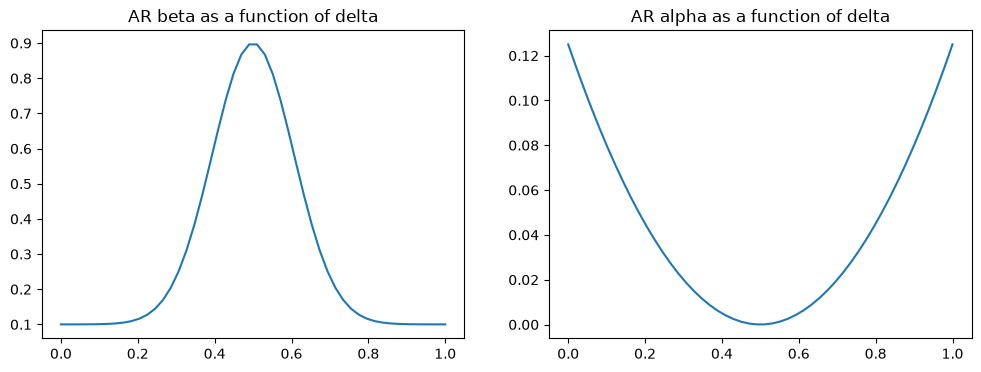

In [3]:
def beta_fn(delta):
    return 0.1 + 0.8 * np.exp(-(((delta - 0.5) / 0.15) ** 2))


def alpha_fn(delta):
    return 0.5 * (delta - 0.5) ** 2


test_delta = np.linspace(0, 1)


fig, ax = plt.subplots(1, 2, figsize=[12, 4])
ax[0].plot(test_delta, beta_fn(test_delta))
ax[0].set_title("AR beta as a function of delta")

ax[1].plot(test_delta, alpha_fn(test_delta))
ax[1].set_title("AR alpha as a function of delta")

Datapoints are related to their neighbours by a kernel function. We take the average over a neighbourhood weighted by this kernel.

In [20]:
kernel_bandwitch = 0.05

kernel = lambda d: np.exp(-(d**2) / (2 * kernel_bandwitch**2))


def neighbourhood_expectation(x_new, x_prev, y_prev):
    distances = np.abs(x_new[:, None] - x_prev[None, :])
    weights = kernel(distances)
    return (weights @ y_prev) / weights.sum(axis=1)

With all this information, we can define our toy dataset 

In [21]:
num_timestamps = 1000
n = 100  # Number of samples to take per timestamp

noise_std = 0.3

x_prev = np.random.rand(n)
y_prev = np.random.normal(scale=noise_std, size=n)

frames = [
    pl.DataFrame(
        {
            "delta": x_prev,
            "t": 0,
            "y": y_prev,
        }
    )
]

for t in range(1, num_timestamps):
    x_t = np.random.rand(n)
    neighbourhood_lag_feature = neighbourhood_expectation(x_t, x_prev, y_prev)
    y_t = (
        beta_fn(x_t) * neighbourhood_lag_feature
        + alpha_fn(x_t)
        + np.random.normal(scale=noise_std, size=n)
    )
    frames.append(
        pl.DataFrame(
            {"delta": x_t, "t": t, "y": y_t, "y_lag": neighbourhood_lag_feature}
        )
    )
    x_prev, y_prev = x_t, y_t

df = pl.concat(frames, how="diagonal")

In [22]:
# We need y_{t-1} as a feature to feed into our model
df = df.with_columns(y_t_minus_1=pl.col("y").shift(1))

<Axes: ylabel='t'>

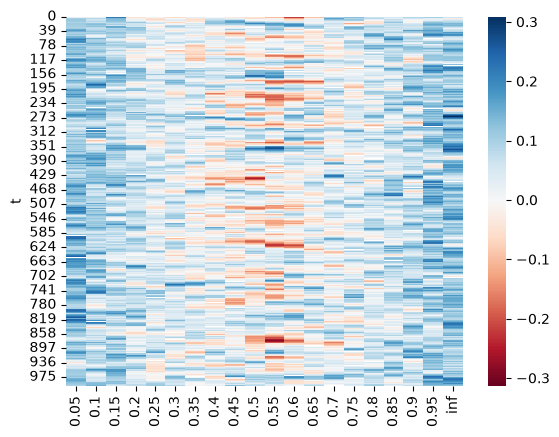

In [23]:
# Before doing any modelling, we can see the autoregressive-geometric structure by doing some simple visualisation
plot = (
    df.with_columns(
        delta_bin=pl.col("delta")
        .cut(0.05 * np.arange(20), include_breaks=True)
        .struct.field("breakpoint")
        .round(2)
        .cast(pl.String)
    )
    .group_by("delta_bin", "t")
    .agg(pl.col("y").mean())
    .sort("delta_bin", "t")
    .with_columns(
        rolling_y=pl.col("y").rolling_mean_by("t", window_size="10i").over("delta_bin")
    )
)

sns.heatmap(
    plot.pivot(index="t", on="delta_bin", values="rolling_y")
    .sort("t")
    .to_pandas()
    .set_index("t"),
    cmap="RdBu",
)

## Model inference

We can see a pattern in the data above, but how can we quantify it? The simplest thing we could do is infer the parameters ($\alpha, \beta$) that paramaterise the autoregression process using a linear regression.

We can do this naiively by ignoring the geometric structure, but it gives us bad results. You can see this in the plots below, where we show the naiively inferred parameters (red line) against the true correlation structure (blue line).

In [ ]:
class LinearRegression:
    def __init__(self):
        self.slope = None
        self.intercept = None

    def fit(self, training_set: pl.DataFrame):
        result = linregress(
            training_set["y_lag"].to_numpy(), training_set["y"].to_numpy()
        )
        self.slope = result.slope
        self.intercept = result.intercept

    def predict(self, df: pl.DataFrame):
        return self.slope * df["y_lag"].to_numpy() + self.intercept

In [25]:
naiive_lr = LinearRegression()
naiive_lr.fit(df.drop_nulls("y_lag"))
print(f"Slope: {naiive_lr.slope: .2f}", f"Intercept: {naiive_lr.intercept:.2f}")

Slope:  0.47 Intercept: 0.03


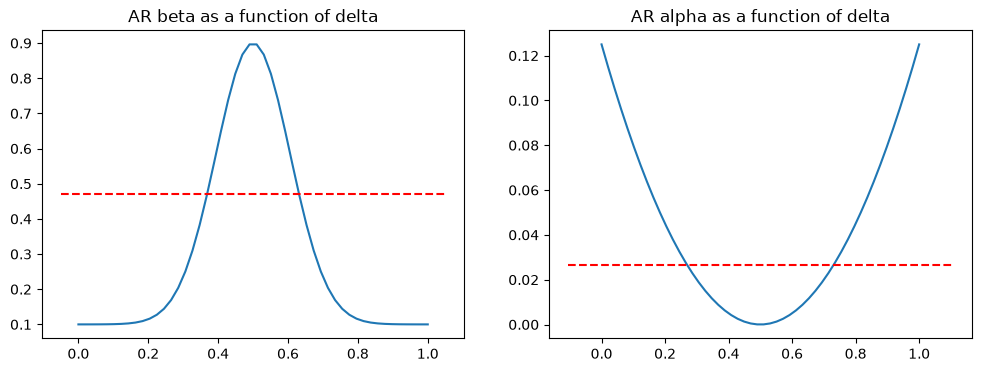

In [26]:
fig, ax = plt.subplots(1, 2, figsize=[12, 4])
ax[0].plot(test_delta, beta_fn(test_delta))
ax[0].set_title("AR beta as a function of delta")
ax[0].hlines(naiive_lr.slope, *ax[0].get_xlim(), color="red", linestyle="--")

ax[1].plot(test_delta, alpha_fn(test_delta))
ax[1].set_title("AR alpha as a function of delta")
ax[1].hlines(naiive_lr.intercept, *ax[0].get_xlim(), color="red", linestyle="--")

### Using lift to model geometric structure

Instead, we can use 'lift' to take the geometric structure into account, training separate models on small patches of delta-space. This time, we fully recover the correlation structure.

In [27]:
linear_regression = leaf(LinearRegression, label="lr")

In [ ]:
geometric_linear_regression = lift(
    linear_regression,
    values=np.round(np.arange(1, 20) * 0.05),
    name="delta_space_lr",
    train_filter=lambda value: (pl.col("delta") - value).abs() < 0.05,
    test_filter=lambda value: (pl.col("delta") - value).abs() < 0.05,
)

In [29]:
geometric_linear_regression.fit(df.drop_nulls("y_lag"))

<Axes: title={'center': 'AR alpha as a function of delta'}, xlabel='delta_bin'>

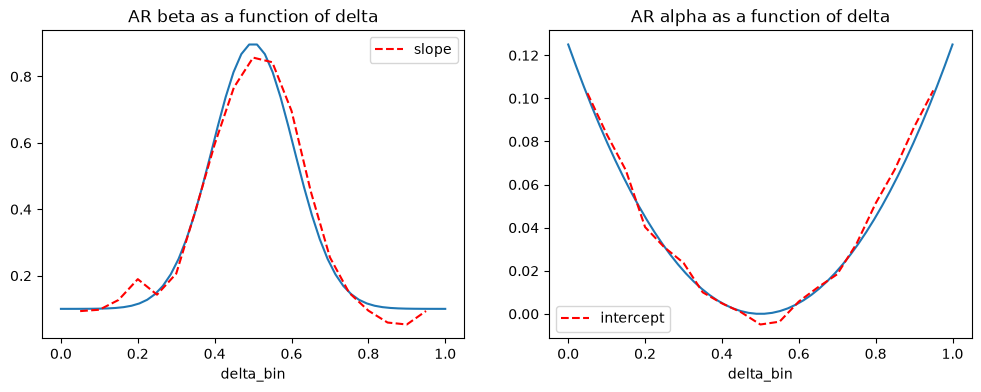

In [30]:
geometric_lr_results = []
for label, model in geometric_linear_regression.fitted.items():
    geometric_lr_results.append(
        {
            "delta_bin": float(label.split("=")[1].strip("]")),
            "slope": model.slope,
            "intercept": model.intercept,
        }
    )

inference_results = pl.from_dicts(geometric_lr_results)

fig, ax = plt.subplots(1, 2, figsize=[12, 4])
ax[0].plot(test_delta, beta_fn(test_delta))
ax[0].set_title("AR beta as a function of delta")
inference_results.to_pandas().plot(
    x="delta_bin", y="slope", color="red", linestyle="--", ax=ax[0]
)

ax[1].plot(test_delta, alpha_fn(test_delta))
ax[1].set_title("AR alpha as a function of delta")
inference_results.to_pandas().plot(
    x="delta_bin", y="intercept", color="red", linestyle="--", ax=ax[1]
)